# Cuaderno 5 — Portafolio de inversión basado en predicciones del modelo

**Tesis:** Predicción del Punto de Equilibrio de Flujo de Caja en Empresas de Crecimiento del Sector Tecnológico

**Universidad EAFIT · 2026**

---

## ¿Qué hace este cuaderno?

Los cuadernos anteriores construyeron y validaron un modelo que predice si
una empresa tecnológica alcanzará el punto de equilibrio de flujo de caja
en los próximos 4 trimestres. Este cuaderno lleva ese modelo a la práctica:
**¿en qué empresas tecnológicas debería invertir hoy un inversionista que
confía en el modelo?**

---

## Criterios de construcción del portafolio

| Criterio | Valor | Justificación |
|---|---|---|
| Probabilidad mínima | ≥ 0.60 | Supera ampliamente el baseline aleatorio (0.567) con margen de confianza razonable |
| Máximo por subsector | 3 empresas | Evita concentración excesiva en subsectores dominantes como Software |
| Historia mínima | 8 trimestres (2 años) | Garantiza que el modelo tiene suficientes datos históricos para predecir con confianza |
| Universo | Empresas tecnológicas con FCF negativo hoy | La pregunta aplica solo a empresas que actualmente queman caja |

---

## Nota sobre el horizonte de inversión

El modelo predice el breakeven en un horizonte de **4 trimestres** —
aproximadamente 12 meses. Esto no es una recomendación de inversión.

> **Aviso legal:** Este análisis es exclusivamente académico. No constituye
> asesoría financiera ni recomendación de inversión.

## 1. Configuración inicial y carga de modelos

In [14]:
import shap
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

warnings.filterwarnings("ignore")

tech_colors = ['#101B4B', '#545E85', '#A3A8B2', '#E7E7E7', '#0F19C9', '#F6D673']
FUENTE = "STIXGeneral"

def estilo_ax(ax, orientacion="vertical"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    if orientacion == "vertical":
        ax.spines["left"].set_visible(False)
        ax.yaxis.grid(True, linestyle="-", color=tech_colors[3], linewidth=0.8)
        ax.xaxis.grid(False)
    else:
        ax.spines["bottom"].set_visible(False)
        ax.xaxis.grid(True, linestyle="-", color=tech_colors[3], linewidth=0.8)
        ax.yaxis.grid(False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

with open("../salidas/modelo_rf_final_tech.pkl", "rb") as f:
    rf_final = pickle.load(f)
with open("../salidas/modelo_lgbm_final_tech.pkl", "rb") as f:
    lgbm_final = pickle.load(f)

features_con_momentum = pd.read_csv("../salidas/features_modelo_tech.csv").iloc[:, 0].tolist()

print(f"Modelos cargados: Random Forest + LightGBM (ensemble tecnológico)")
print(f"Features del modelo: {len(features_con_momentum)}")

Modelos cargados: Random Forest + LightGBM (ensemble tecnológico)
Features del modelo: 65


## 2. Preparación de datos

Se parte del dataset crudo tecnológico filtrado en el Cuaderno 1
(`variables_financieras_tech.csv.gz`), que contiene los reportes más
recientes disponibles en SEC EDGAR. Se aplica el mismo pipeline de
limpieza y transformación del Cuaderno 2, conservando **toda la historia**
de cada empresa para calcular correctamente las features temporales, y
tomando al final solo el **trimestre más reciente** de cada una.

In [15]:
df_crudo = pd.read_csv(
    "../datos/crudos/variables_financieras_tech.csv.gz",
    compression="gzip"
)
df_crudo["start"] = pd.to_datetime(df_crudo["start"], errors="coerce")
df_crudo["end"]   = pd.to_datetime(df_crudo["end"],   errors="coerce")
df_crudo["fy"]    = pd.to_numeric(df_crudo["fy"], errors="coerce").astype("Int32")

print(f"Dataset crudo tecnológico cargado: {df_crudo.shape}")
print(f"Período: {df_crudo['end'].min().date()} → {df_crudo['end'].max().date()}")

variables_balance = [
    "activos_corrientes", "activos_totales", "caja",
    "cuentas_por_cobrar", "cuentas_por_pagar", "deuda_corto_plazo",
    "deuda_largo_plazo", "inventario", "pasivos_corrientes",
    "activos_intangibles", "goodwill", "ppe_neto", "patrimonio",
    "retained_earnings", "ingresos_diferidos", "impuestos_pagados",
    "acciones_circulacion"
]

df_crudo = df_crudo[(df_crudo["end"].dt.year >= 2000) & (df_crudo["end"].dt.year <= 2026)].copy()

df_balance = df_crudo[df_crudo["variable"].isin(variables_balance)].copy()
df_flujo   = df_crudo[~df_crudo["variable"].isin(variables_balance)].copy()
df_balance = df_balance[df_balance["fp"].isin(["Q1", "Q2", "Q3", "Q4"])].copy()

df_flujo["duracion_dias"] = (df_flujo["end"] - df_flujo["start"]).dt.days
df_flujo_puro = df_flujo[df_flujo["duracion_dias"].between(80, 100)].copy()
df_flujo_acum = df_flujo[
    ~df_flujo["duracion_dias"].between(80, 100) &
    df_flujo["duracion_dias"].between(150, 400)
].copy()

df_flujo_acum = df_flujo_acum.sort_values(["ticker", "variable", "fy", "end"])
df_flujo_acum["val_anterior"] = df_flujo_acum.groupby(
    ["ticker", "variable", "fy"], observed=True
)["val"].shift(1)
df_flujo_acum["val_trimestral"] = df_flujo_acum["val"] - df_flujo_acum["val_anterior"]
mask_q1 = df_flujo_acum["val_anterior"].isna()
df_flujo_acum.loc[mask_q1, "val_trimestral"] = df_flujo_acum.loc[mask_q1, "val"]
df_flujo_acum = df_flujo_acum.dropna(subset=["val_trimestral"]).copy()
df_flujo_acum["val"] = df_flujo_acum["val_trimestral"].astype("float32")
df_flujo_acum = df_flujo_acum.drop(columns=["val_anterior", "val_trimestral", "duracion_dias"])

df_flujo_final = pd.concat([
    df_flujo_puro.drop(columns=["duracion_dias"]), df_flujo_acum
], ignore_index=True)

df_limpio = pd.concat([df_flujo_final, df_balance], ignore_index=True)
df_ancho  = df_limpio.pivot_table(
    index=["ticker", "sector", "bolsa", "end"],
    columns="variable", values="val", aggfunc="mean", observed=True
).reset_index()
df_ancho.columns.name = None
df_ancho = df_ancho.sort_values(["ticker", "end"]).reset_index(drop=True)

print(f"Shape después del pivot: {df_ancho.shape}")
print(f"Empresas: {df_ancho['ticker'].nunique():,}")

# --- Variables derivadas ---
df_ancho["burn_rate"]        = df_ancho["fcf_operativo"].abs()
df_ancho["runway"]           = df_ancho["caja"] / df_ancho["burn_rate"]
df_ancho["capital_trabajo"]  = df_ancho["activos_corrientes"] - df_ancho["pasivos_corrientes"]
df_ancho["margen_bruto"]     = df_ancho["utilidad_bruta"] / df_ancho["ingresos"]
df_ancho["margen_operativo"] = df_ancho["utilidad_operativa"] / df_ancho["ingresos"]
df_ancho["margen_neto"]      = df_ancho["utilidad_neta"] / df_ancho["ingresos"]
df_ancho["ratio_id"]         = df_ancho["gastos_id"] / df_ancho["ingresos"]
df_ancho["ratio_deuda"]      = df_ancho["deuda_largo_plazo"] / df_ancho["activos_totales"]
df_ancho["ratio_corriente"]  = df_ancho["activos_corrientes"] / df_ancho["pasivos_corrientes"]
df_ancho["rotacion_activos"] = df_ancho["ingresos"] / df_ancho["activos_totales"]
df_ancho["intensidad_capex"] = df_ancho["capex"].abs() / df_ancho["ingresos"]

for var in ["runway", "burn_rate", "capital_trabajo", "margen_bruto",
            "margen_operativo", "margen_neto", "ratio_id", "ratio_deuda",
            "ratio_corriente", "rotacion_activos", "intensidad_capex"]:
    p01 = df_ancho[var].quantile(0.01)
    p99 = df_ancho[var].quantile(0.99)
    df_ancho[var] = df_ancho[var].clip(lower=p01, upper=p99)

# --- Features temporales ---
df_ancho = df_ancho.sort_values(["ticker", "end"])
vars_momentum = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate", "margen_bruto", "ingresos"]
vars_rezago   = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate"]

for var in vars_momentum:
    df_ancho[f"{var}_cambio"]     = df_ancho.groupby("ticker", observed=True)[var].diff()
    df_ancho[f"{var}_cambio_pct"] = df_ancho.groupby("ticker", observed=True)[var].pct_change(fill_method=None)
for var in vars_rezago:
    df_ancho[f"{var}_lag2"] = df_ancho.groupby("ticker", observed=True)[var].shift(2)
    df_ancho[f"{var}_lag4"] = df_ancho.groupby("ticker", observed=True)[var].shift(4)

df_ancho[features_con_momentum] = df_ancho[features_con_momentum].replace([np.inf, -np.inf], np.nan)

print(f"Features temporales construidas.")
print(f"Shape final: {df_ancho.shape}")

Dataset crudo tecnológico cargado: (640523, 13)
Período: 2007-04-04 → 2026-02-01
Shape después del pivot: (10988, 44)
Empresas: 256
Features temporales construidas.
Shape final: (10988, 75)


## 3. Selección del universo de predicción

Se toma el **trimestre más reciente disponible** para cada empresa. Solo
se incluyen empresas que:
- Tienen FCF operativo negativo en su último trimestre (queman caja hoy)
- Tienen al menos 8 trimestres de historia (2 años) para que las features
  temporales sean confiables

In [16]:
df_reciente = (
    df_ancho.sort_values("end")
    .groupby("ticker", observed=True)
    .last()
    .reset_index()
)

conteo = df_ancho.groupby("ticker", observed=True).size().reset_index(name="n_trimestres")
df_reciente = df_reciente.merge(conteo, on="ticker")

df_candidatas = df_reciente[
    (df_reciente["fcf_operativo"] < 0) &
    (df_reciente["n_trimestres"] >= 8)
].copy().reset_index(drop=True)

print(f"Empresas con datos recientes: {len(df_reciente):,}")
print(f"Con FCF negativo y ≥2 años de historia: {len(df_candidatas):,}")
print(f"\nFecha del último reporte disponible:")
print(df_candidatas["end"].dt.to_period("Q").value_counts().sort_index(ascending=False).head(5))

Empresas con datos recientes: 256
Con FCF negativo y ≥2 años de historia: 45

Fecha del último reporte disponible:
end
2026Q1     3
2025Q4    38
2025Q3     4
Freq: Q-DEC, Name: count, dtype: int64


## 4. Predicciones del ensemble

Se aplica el ensemble de Random Forest y LightGBM — el modelo con AUC-PR
de 0.783 en el walk-forward validation — para generar una probabilidad de
breakeven en los próximos 4 trimestres para cada empresa candidata.

Distribución de probabilidades de breakeven:
count    45.000
mean      0.470
std       0.192
min       0.095
25%       0.280
50%       0.462
75%       0.635
max       0.840

Empresas por umbral de probabilidad:
  ≥ 0.50:  21 empresas (46.7%)
  ≥ 0.60:  15 empresas (33.3%)
  ≥ 0.70:   5 empresas (11.1%)
  ≥ 0.80:   1 empresas (2.2%)


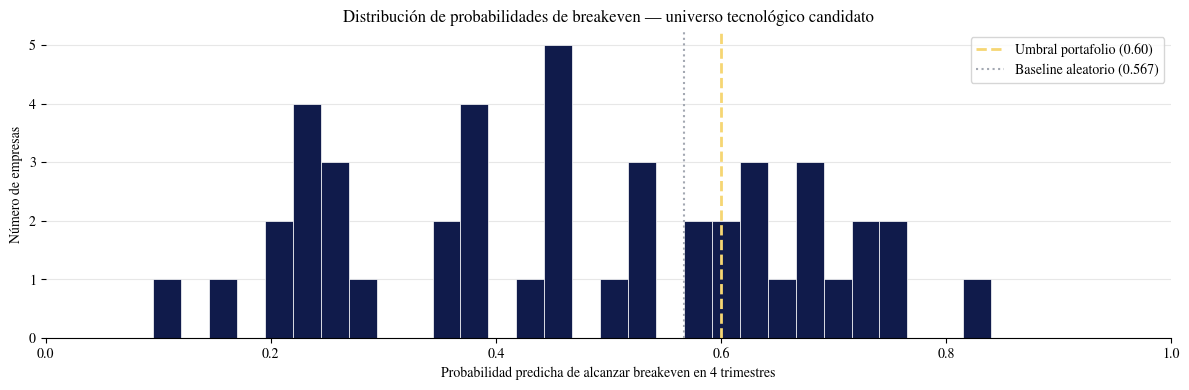

In [17]:
prob_rf   = rf_final.predict_proba(df_candidatas[features_con_momentum].values)[:, 1]
prob_lgbm = lgbm_final.predict_proba(df_candidatas[features_con_momentum].values)[:, 1]
df_candidatas["prob_breakeven"] = (prob_rf + prob_lgbm) / 2

print(f"Distribución de probabilidades de breakeven:")
print(df_candidatas["prob_breakeven"].describe().round(3).to_string())
print(f"\nEmpresas por umbral de probabilidad:")
for umbral in [0.50, 0.60, 0.70, 0.80]:
    n = (df_candidatas["prob_breakeven"] >= umbral).sum()
    print(f"  ≥ {umbral:.2f}: {n:>3} empresas ({n/len(df_candidatas)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 4))
estilo_ax(ax)
ax.hist(df_candidatas["prob_breakeven"], bins=30,
        color=tech_colors[0], edgecolor="white", linewidth=0.5)
ax.axvline(0.60, color=tech_colors[5], linewidth=2,
           linestyle="--", label="Umbral portafolio (0.60)")
ax.axvline(0.567, color=tech_colors[2], linewidth=1.5,
           linestyle=":", label="Baseline aleatorio (0.567)")
ax.set_title("Distribución de probabilidades de breakeven — universo tecnológico candidato",
             fontfamily=FUENTE, fontsize=12)
ax.set_xlabel("Probabilidad predicha de alcanzar breakeven en 4 trimestres", fontfamily=FUENTE)
ax.set_ylabel("Número de empresas", fontfamily=FUENTE)
ax.legend(prop={"family": FUENTE})
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

HITO 5 — Parte 1-4: Preparación de datos y predicciones del ensemble
==================================================================
Fecha: [completar]
Notebook: 05_portafolio_tech.ipynb

Qué se hizo:
- Se reconstruyó el pipeline completo (limpieza, destrimestralización,
  pivot, variables derivadas y temporales) sobre el dataset crudo
  tecnológico, conservando toda la historia de cada empresa.
- Se seleccionó el trimestre más reciente de cada empresa, filtrando a
  quienes tienen FCF operativo negativo actual y al menos 8 trimestres
  de historia.
- Se aplicó el ensemble (RF + LightGBM) para predecir la probabilidad
  de breakeven en los próximos 4 trimestres.

Resultado:
- 45 empresas candidatas (FCF negativo + historia suficiente)
- Probabilidad media: 0.470 | mínima: 0.095 | máxima: 0.840
- 21 empresas (46.7%) superan el umbral de 0.50
- 15 empresas (33.3%) superan el umbral de 0.60 (criterio del portafolio)
- Solo 1 empresa (2.2%) supera 0.80 -- probabilidades máximas más
  moderadas que en un universo multisectorial más amplio, coherente
  con un universo más pequeño y menos heterogéneo.

Importancia:
Confirma que el modelo, aplicado a datos actuales, genera un rango
amplio y bien distribuido de probabilidades -- no colapsa en valores
extremos -- proporcionando una base sólida de 15 candidatas para
construir el portafolio final en la siguiente sección.

## 5. Construcción del portafolio

Se aplican los tres criterios de selección:
1. **Probabilidad ≥ 0.60** — umbral de confianza mínima
2. **Máximo 3 empresas por subsector tecnológico** — diversificación
3. **Ordenadas por probabilidad descendente** — las mejores oportunidades primero

Para cada empresa se calculan los valores SHAP del ensemble, que explican
cuáles variables empujan la predicción hacia el breakeven y cuáles la frenan.

In [18]:
UMBRAL          = 0.60
MAX_POR_SECTOR  = 3

df_portafolio = (
    df_candidatas[df_candidatas["prob_breakeven"] >= UMBRAL]
    .sort_values("prob_breakeven", ascending=False)
    .groupby("sector", observed=True)
    .head(MAX_POR_SECTOR)
    .sort_values("prob_breakeven", ascending=False)
    .reset_index(drop=True)
)

X_rf_port   = rf_final.named_steps["imputer"].transform(
    df_portafolio[features_con_momentum].values)
X_lgbm_port = lgbm_final.named_steps["imputer"].transform(
    df_portafolio[features_con_momentum].values)

shap_rf_port   = shap.TreeExplainer(rf_final.named_steps["model"]).shap_values(X_rf_port)
shap_lgbm_port = shap.TreeExplainer(lgbm_final.named_steps["model"]).shap_values(X_lgbm_port)

sv_rf_port   = shap_rf_port[1] if isinstance(shap_rf_port, list) else shap_rf_port[:, :, 1]
sv_lgbm_port = shap_lgbm_port[1] if isinstance(shap_lgbm_port, list) else shap_lgbm_port
sv_port      = (sv_rf_port + sv_lgbm_port) / 2

def top3_favor(shap_row):
    s = pd.Series(shap_row, index=features_con_momentum)
    top = s[s > 0].nlargest(3)
    return ", ".join([f"{v} (+{x:.3f})" for v, x in top.items()]) if len(top) > 0 else "—"

def top3_contra(shap_row):
    s = pd.Series(shap_row, index=features_con_momentum)
    top = s[s < 0].nsmallest(3)
    return ", ".join([f"{v} ({x:.3f})" for v, x in top.items()]) if len(top) > 0 else "—"

df_portafolio["razones_favor"]  = [top3_favor(sv_port[i])  for i in range(len(df_portafolio))]
df_portafolio["razones_contra"] = [top3_contra(sv_port[i]) for i in range(len(df_portafolio))]

print(f"Portafolio construido:")
print(f"  Empresas seleccionadas: {len(df_portafolio)}")
print(f"  Subsectores representados: {df_portafolio['sector'].nunique()}")
print(f"  Probabilidad media:     {df_portafolio['prob_breakeven'].mean():.3f}")
print(f"  Probabilidad mínima:    {df_portafolio['prob_breakeven'].min():.3f}")
print(f"  Probabilidad máxima:    {df_portafolio['prob_breakeven'].max():.3f}")

Portafolio construido:
  Empresas seleccionadas: 14
  Subsectores representados: 7
  Probabilidad media:     0.688
  Probabilidad mínima:    0.600
  Probabilidad máxima:    0.840


HITO 5 — Parte 5: Construcción del portafolio final
==================================================================
Fecha: 17/08/2026
Notebook: 05_portafolio_tech.ipynb

Qué se hizo:
- Se aplicaron los criterios de selección (probabilidad ≥ 0.60, máximo
  3 empresas por subsector) sobre las 45 empresas candidatas.
- Se calcularon los valores SHAP del ensemble para cada empresa
  seleccionada, extrayendo las 3 variables con mayor impacto a favor
  y en contra de cada predicción.

Resultado:
- 14 empresas en el portafolio final (de 15 que superaban el umbral --
  el criterio de diversificación por subsector excluyó solo 1)
- 7 subsectores tecnológicos representados
- Probabilidad media: 0.688 | mínima: 0.600 | máxima: 0.840

Importancia:
El portafolio resultante está razonablemente diversificado (7 de los
~10 subsectores tecnológicos del universo), sin que ningún subsector
domine de forma desproporcionada -- resultado natural dado el tamaño
más acotado del universo tecnológico frente a un análisis
multisectorial.

## 6. Visualizaciones del portafolio

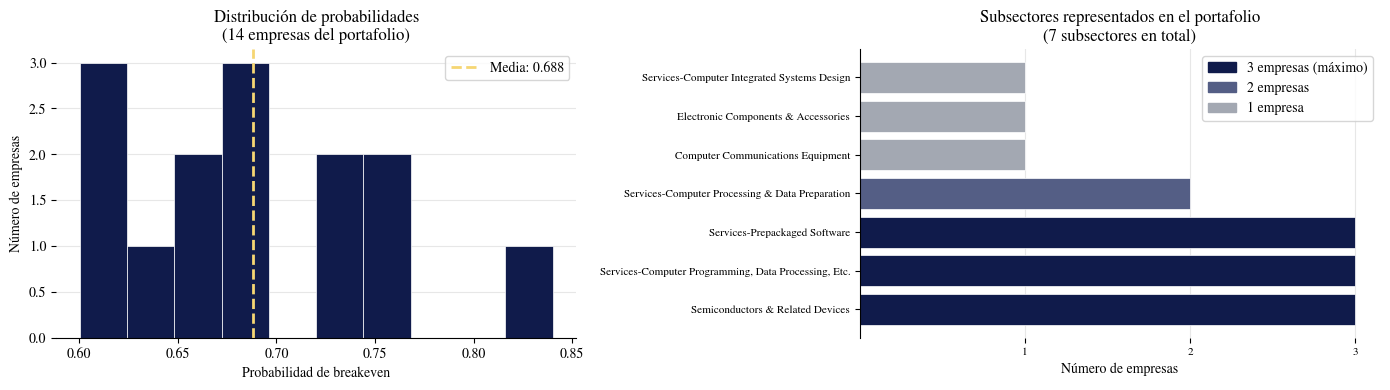

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de probabilidades
estilo_ax(axes[0])
axes[0].hist(df_portafolio["prob_breakeven"], bins=10,
             color=tech_colors[0], edgecolor="white", linewidth=0.5)
axes[0].axvline(df_portafolio["prob_breakeven"].mean(),
                color=tech_colors[5], linewidth=2, linestyle="--",
                label=f"Media: {df_portafolio['prob_breakeven'].mean():.3f}")
axes[0].set_title(f"Distribución de probabilidades\n({len(df_portafolio)} empresas del portafolio)",
                  fontfamily=FUENTE, fontsize=12)
axes[0].set_xlabel("Probabilidad de breakeven", fontfamily=FUENTE)
axes[0].set_ylabel("Número de empresas", fontfamily=FUENTE)
axes[0].legend(prop={"family": FUENTE})

# Subsectores representados
estilo_ax(axes[1], "horizontal")
conteo_sector = df_portafolio["sector"].value_counts()
colores_sector = [tech_colors[0] if v == 3 else
                  tech_colors[1] if v == 2 else
                  tech_colors[2] for v in conteo_sector.values]
axes[1].barh(conteo_sector.index, conteo_sector.values,
             color=colores_sector, edgecolor="white", linewidth=0.5)
axes[1].set_title(f"Subsectores representados en el portafolio\n"
                  f"({df_portafolio['sector'].nunique()} subsectores en total)",
                  fontfamily=FUENTE, fontsize=12)
axes[1].set_xlabel("Número de empresas", fontfamily=FUENTE)
axes[1].set_xticks([1, 2, 3])
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontfamily(FUENTE)
    label.set_fontsize(8)

p1 = mpatches.Patch(color=tech_colors[0], label="3 empresas (máximo)")
p2 = mpatches.Patch(color=tech_colors[1], label="2 empresas")
p3 = mpatches.Patch(color=tech_colors[2], label="1 empresa")
axes[1].legend(handles=[p1, p2, p3], prop={"family": FUENTE}, fontsize=8)

plt.tight_layout()
plt.show()

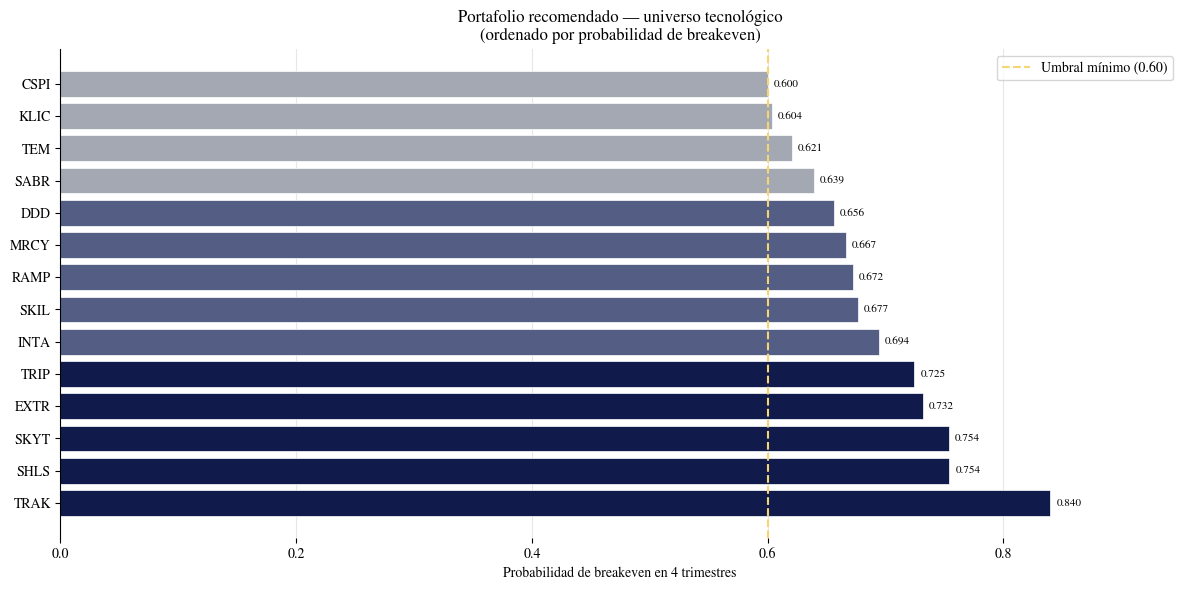

In [20]:
# --- Todas las empresas del portafolio, ordenadas por probabilidad ---
fig, ax = plt.subplots(figsize=(12, 6))
estilo_ax(ax, "horizontal")

colores_bar = [
    tech_colors[0] if p >= 0.70 else
    tech_colors[1] if p >= 0.65 else
    tech_colors[2] for p in df_portafolio["prob_breakeven"]
]
bars = ax.barh(df_portafolio["ticker"], df_portafolio["prob_breakeven"],
               color=colores_bar, edgecolor="white", linewidth=0.5)
ax.axvline(0.60, color=tech_colors[5], linewidth=1.5,
           linestyle="--", label="Umbral mínimo (0.60)")

for bar, prob in zip(bars, df_portafolio["prob_breakeven"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{prob:.3f}", va="center", fontfamily=FUENTE, fontsize=8)

ax.set_xlabel("Probabilidad de breakeven en 4 trimestres", fontfamily=FUENTE)
ax.set_title("Portafolio recomendado — universo tecnológico\n(ordenado por probabilidad de breakeven)",
             fontfamily=FUENTE, fontsize=12)
ax.set_xlim(0, 0.95)
ax.legend(prop={"family": FUENTE})
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)
plt.tight_layout()
plt.show()

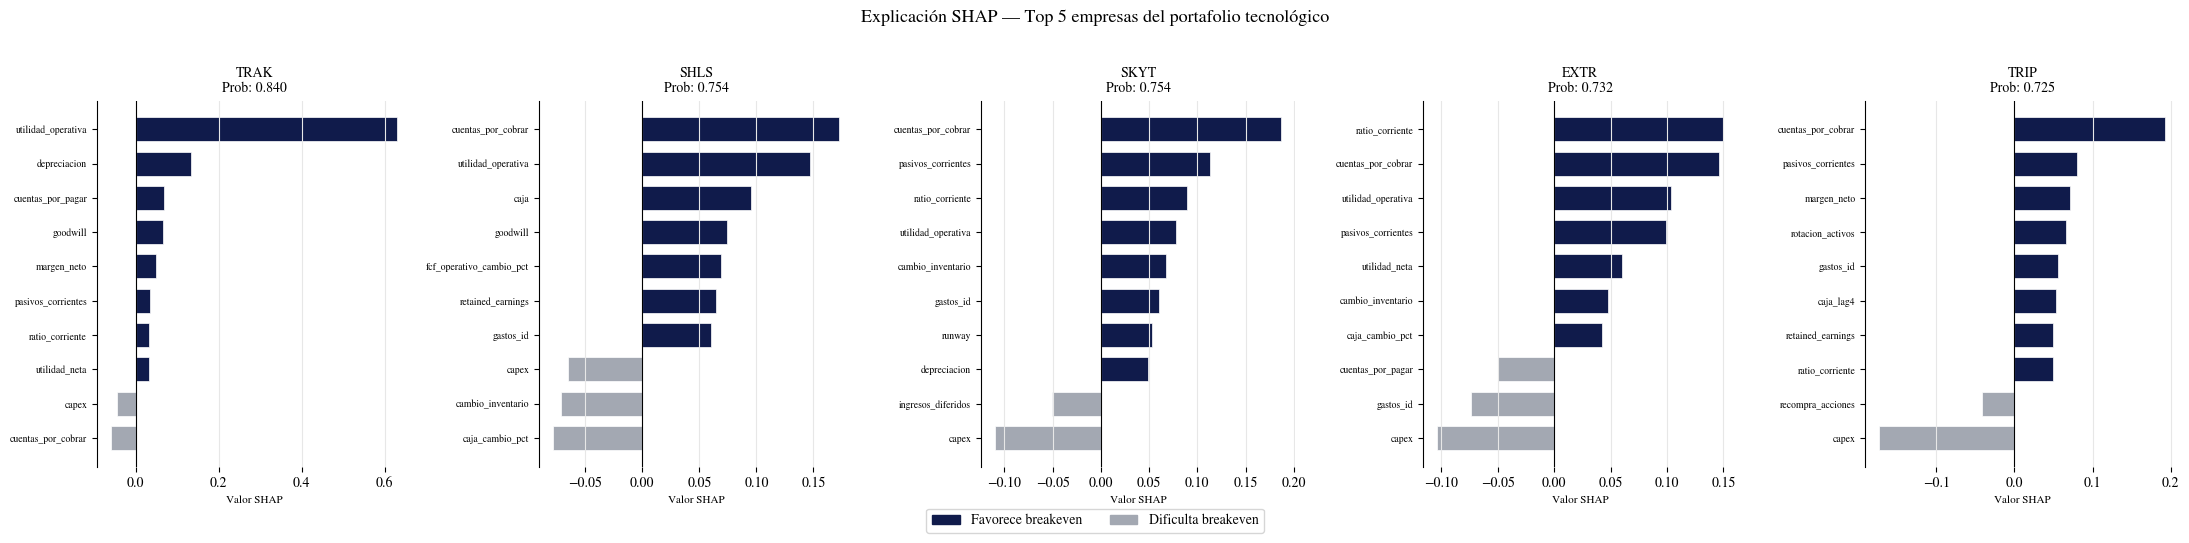

In [21]:
# --- SHAP waterfall para las top 5 empresas ---
top5 = df_portafolio.head(5)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for ax, (_, empresa) in zip(axes, top5.iterrows()):
    idx       = empresa.name
    shap_emp  = pd.Series(sv_port[idx], index=features_con_momentum)
    top10     = shap_emp.abs().nlargest(10).index
    shap_top  = shap_emp[top10].sort_values()

    colores_wf = [tech_colors[0] if v > 0 else tech_colors[2]
                  for v in shap_top.values]
    ax.barh(range(len(shap_top)), shap_top.values,
            color=colores_wf, edgecolor="white", linewidth=0.5, height=0.7)
    ax.set_yticks(range(len(shap_top)))
    ax.set_yticklabels(shap_top.index, fontfamily=FUENTE, fontsize=7)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{empresa['ticker']}\nProb: {empresa['prob_breakeven']:.3f}",
                 fontfamily=FUENTE, fontsize=10)
    ax.set_xlabel("Valor SHAP", fontfamily=FUENTE, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.xaxis.grid(True, linestyle="-", color=tech_colors[3], linewidth=0.8)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

patch_pos = mpatches.Patch(color=tech_colors[0], label="Favorece breakeven")
patch_neg = mpatches.Patch(color=tech_colors[2], label="Dificulta breakeven")
fig.legend(handles=[patch_pos, patch_neg], prop={"family": FUENTE},
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.04))
plt.suptitle("Explicación SHAP — Top 5 empresas del portafolio tecnológico",
             fontfamily=FUENTE, fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

HITO 5 — Parte 6: Visualizaciones del portafolio
==================================================================
Fecha: 17/08/2026
Notebook: 05_portafolio_tech.ipynb

Qué se hizo:
- Se generaron tres visualizaciones: distribución de probabilidades del
  portafolio, subsectores representados, y explicación SHAP individual
  de las 5 empresas con mayor probabilidad.

Resultado:
- Portafolio de 14 empresas, probabilidades entre 0.600 (CSPI) y 0.840
  (TRAK), con media de 0.688.
- 7 subsectores representados, sin concentración excesiva: 3 subsectores
  con el máximo de 3 empresas (Semiconductores, Software, Computer
  Programming), y el resto con 1-2 empresas.
- En las 5 empresas de mayor probabilidad, cuentas_por_cobrar, pasivos_
  corrientes y utilidad_operativa aparecen consistentemente como señales
  favorables, mientras que capex aparece como señal desfavorable en
  todos los casos -- un matiz relevante frente al hallazgo SHAP global
  del Cuaderno 4, donde capex era la variable más favorable en promedio,
  ilustrando que el efecto agregado no siempre se replica igual en cada
  caso individual (coherente con el patrón de umbral identificado en
  los dependence plots).

Importancia:
Presenta un portafolio tecnológico concreto, diversificado y explicado
variable por variable, cerrando la aplicación práctica del modelo
predictivo desarrollado en los cuadernos anteriores.

## 7. Portafolio completo

La siguiente tabla muestra todas las empresas seleccionadas con sus
variables financieras clave y la explicación del modelo. Las columnas
**razones a favor** y **razones en contra** muestran las 3 variables SHAP
con mayor impacto positivo y negativo respectivamente, con el valor de
su contribución entre paréntesis.

**Cómo leer la tabla:**
- `prob_breakeven`: probabilidad de alcanzar FCF positivo en los
  próximos 4 trimestres
- `end`: fecha del último reporte financiero disponible
- `fcf_operativo`: quema de caja trimestral actual en USD
- `burn_rate`: valor absoluto del FCF operativo — cuánto efectivo
  consume por trimestre
- `capex`: inversión en activos físicos — negativo indica salida de caja

In [22]:
cols_display = [
    "ticker", "sector", "prob_breakeven", "end",
    "fcf_operativo", "burn_rate", "capex",
    "razones_favor", "razones_contra"
]

df_display = df_portafolio[cols_display].copy()
df_display["prob_breakeven"] = df_display["prob_breakeven"].round(3)
df_display["fcf_operativo"]  = (df_display["fcf_operativo"] / 1e6).round(1).astype(str) + "M"
df_display["burn_rate"]      = (df_display["burn_rate"] / 1e6).round(1).astype(str) + "M"
df_display["capex"] = df_portafolio["capex"].apply(
    lambda x: f"{x/1e6:.2f}M" if abs(x) >= 100_000 else f"{x/1e3:.0f}K"
)
df_display["end"]            = df_display["end"].dt.to_period("Q").astype(str)

df_display.columns = [
    "Ticker", "Sector", "Prob. Breakeven", "Último reporte",
    "FCF operativo", "Burn rate", "Capex",
    "Razones a favor (SHAP)", "Razones en contra (SHAP)"
]

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 100)
print(f"Portafolio final — {len(df_display)} empresas en {df_portafolio['sector'].nunique()} subsectores")
print(f"Horizonte de predicción: 4 trimestres (~12 meses)")
print()
display(df_display)

Portafolio final — 14 empresas en 7 subsectores
Horizonte de predicción: 4 trimestres (~12 meses)



,Ticker,Sector,Prob. Breakeven,Último reporte,FCF operativo,Burn rate,Capex,Razones a favor (SHAP),Razones en contra (SHAP)
0,TRAK,Services-Computer Processing & Data Preparation,0.840,2025Q4,-1.6M,1.6M,12K,"utilidad_operativa (+0.630), depreciacion (+0.133), cuentas_por_pagar (+0.068)","cuentas_por_cobrar (-0.059), capex (-0.045), caja (-0.025)"
1,SHLS,Semiconductors & Related Devices,0.754,2025Q4,-4.1M,4.1M,7.16M,"cuentas_por_cobrar (+0.172), utilidad_operativa (+0.147), caja (+0.096)","caja_cambio_pct (-0.078), cambio_inventario (-0.071), capex (-0.065)"
2,SKYT,Semiconductors & Related Devices,0.754,2025Q4,-36.1M,36.1M,6.10M,"cuentas_por_cobrar (+0.187), pasivos_corrientes (+0.113), ratio_corriente (+...","capex (-0.109), ingresos_diferidos (-0.050), recompra_acciones (-0.041)"
3,EXTR,Computer Communications Equipment,0.732,2025Q4,-4.0M,4.0M,4.35M,"ratio_corriente (+0.150), cuentas_por_cobrar (+0.146), utilidad_operativa (+...","capex (-0.104), gastos_id (-0.074), cuentas_por_pagar (-0.049)"
4,TRIP,"Services-Computer Programming, Data Processing, Etc.",0.725,2025Q4,-103.0M,103.0M,15.00M,"cuentas_por_cobrar (+0.193), pasivos_corrientes (+0.080), margen_neto (+0.071)","capex (-0.173), recompra_acciones (-0.042), deuda_largo_plazo (-0.039)"
5,INTA,Services-Prepackaged Software,0.694,2025Q4,-13.0M,13.0M,0.81M,"ratio_corriente (+0.185), pasivos_corrientes (+0.132), cuentas_por_cobrar (+...","capex (-0.094), gastos_id (-0.084), ratio_deuda (-0.059)"
6,SKIL,Services-Prepackaged Software,0.677,2025Q4,-18.9M,18.9M,0.47M,"cuentas_por_cobrar (+0.201), recompra_acciones (+0.147), ratio_corriente (+0...","ingresos_diferidos (-0.126), gastos_id (-0.089), acciones_circulacion (-0.076)"
7,RAMP,Services-Computer Processing & Data Preparation,0.672,2025Q4,-4.7M,4.7M,0.16M,"cuentas_por_cobrar (+0.133), utilidad_operativa (+0.094), utilidad_neta (+0....","capex (-0.108), gastos_id (-0.056), fcf_operativo (-0.029)"
8,MRCY,Electronic Components & Accessories,0.667,2025Q4,-17.0M,17.0M,2.66M,"cuentas_por_cobrar (+0.164), pasivos_corrientes (+0.102), depreciacion (+0.079)","capex (-0.070), cuentas_por_pagar (-0.045), recompra_acciones (-0.041)"
9,DDD,Services-Prepackaged Software,0.656,2025Q4,-14.7M,14.7M,1.95M,"cuentas_por_cobrar (+0.183), pasivos_corrientes (+0.121), caja_lag4 (+0.060)","capex (-0.093), gastos_id (-0.079), utilidad_operativa (-0.058)"


In [23]:
ruta_portafolio = "../salidas/portafolio_recomendado_tech.csv"
df_portafolio[cols_display].to_csv(ruta_portafolio, index=False)
print(f"Portafolio guardado: {ruta_portafolio}")
print(f"\nResumen final:")
print(f"  Empresas en portafolio:     {len(df_portafolio)}")
print(f"  Subsectores representados:  {df_portafolio['sector'].nunique()}")
print(f"  Probabilidad media:         {df_portafolio['prob_breakeven'].mean():.3f}")
print(f"  Horizonte de predicción:    4 trimestres (~12 meses)")

Portafolio guardado: ../salidas/portafolio_recomendado_tech.csv

Resumen final:
  Empresas en portafolio:     14
  Subsectores representados:  7
  Probabilidad media:         0.688
  Horizonte de predicción:    4 trimestres (~12 meses)


HITO 5 — Cuaderno completo: Portafolio de inversión tecnológico
==================================================================
Fecha: 19/08/2026
Notebook: 05_portafolio_tech.ipynb

Qué se hizo:
1. Se reconstruyó el pipeline completo sobre datos crudos tecnológicos
   más recientes (hasta Q1 2026), conservando toda la historia por
   empresa para calcular features temporales.
2. Se filtró a empresas con FCF negativo actual y ≥8 trimestres de
   historia (45 candidatas).
3. Se aplicó el ensemble para predecir probabilidad de breakeven.
4. Se construyó el portafolio final: probabilidad ≥0.60, máximo 3 por
   subsector, con explicación SHAP individual por empresa.
5. Se ajustó el formato de presentación de capex (K/M dinámico) tras
   detectar que el redondeo a un decimal en millones ocultaba valores
   pequeños pero reales (ej. TRAK: $11.749 mostrado como "0.0M").

Resultado:
- Portafolio final: 14 empresas, 7 subsectores, probabilidad media 0.688
  (rango 0.600-0.840).
- Empresa líder: TRAK (0.840), impulsada principalmente por
  utilidad_operativa (+0.630).
- Patrón dominante: cuentas_por_cobrar es la razón a favor más frecuente
  (12 de 14 empresas), mientras que capex es la razón en contra más
  frecuente (12 de 14 empresas) -- las empresas que superan el umbral
  de portafolio tienden a tener menor capex relativo dentro del
  universo, compensado por señales más fuertes de actividad comercial
  y rentabilidad operativa.
- Archivo generado: salidas/portafolio_recomendado_tech.csv

Importancia:
Cierra la aplicación práctica del modelo predictivo: un portafolio
concreto, diversificado y explicado variable por variable para el
universo tecnológico, con el aviso legal correspondiente de que el
análisis es exclusivamente académico y no constituye asesoría de
inversión.